# Modeling

Notebook placeholder for modeling.

In [8]:
# ==========================================
# CELL 1 : Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


In [9]:
# ==========================================
# CELL 2 : Load Dataset
# ==========================================

df = pd.read_csv(
    "../data/raw/household_power_consumption.txt",
    sep=";",
    low_memory=False,
    na_values="?"
)

print("Dataset Loaded Successfully!")
print("Shape :", df.shape)

df.head()

Dataset Loaded Successfully!
Shape : (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [10]:
# ==========================================
# CELL 3 : Dataset Overview
# ==========================================

print("First 5 Rows")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

First 5 Rows


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0



Dataset Shape:
(2075259, 9)

Column Names:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Data Types:
Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

Missing Values:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Duplicate Rows:
0


In [11]:
# ==========================================
# CELL 4 : Data Cleaning
# ==========================================

# Numeric Columns
numeric_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

# Convert to Numeric
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill Missing Values
df[numeric_columns] = df[numeric_columns].ffill()
df[numeric_columns] = df[numeric_columns].bfill()

print("Missing Values After Cleaning")
print(df[numeric_columns].isnull().sum())

Missing Values After Cleaning
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [12]:
# ==========================================
# CELL 5 : Feature Engineering
# ==========================================

# Create Datetime Column
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

# Sort by Time
df = df.sort_values("Datetime")

# Set Datetime as Index
df.set_index("Datetime", inplace=True)

# Time Features
df["Hour"] = df.index.hour
df["Day"] = df.index.day
df["Month"] = df.index.month
df["DayOfWeek"] = df.index.dayofweek
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

print("Feature Engineering Completed!")
print(df.head())

Feature Engineering Completed!
                           Date      Time  Global_active_power  \
Datetime                                                         
2006-12-16 17:24:00  16/12/2006  17:24:00                4.216   
2006-12-16 17:25:00  16/12/2006  17:25:00                5.360   
2006-12-16 17:26:00  16/12/2006  17:26:00                5.374   
2006-12-16 17:27:00  16/12/2006  17:27:00                5.388   
2006-12-16 17:28:00  16/12/2006  17:28:00                3.666   

                     Global_reactive_power  Voltage  Global_intensity  \
Datetime                                                                
2006-12-16 17:24:00                  0.418   234.84              18.4   
2006-12-16 17:25:00                  0.436   233.63              23.0   
2006-12-16 17:26:00                  0.498   233.29              23.0   
2006-12-16 17:27:00                  0.502   233.74              23.0   
2006-12-16 17:28:00                  0.528   235.68              15.

In [13]:
# ==========================================
# CELL 6 : Create Lag Features
# ==========================================

# Previous Hour Features
df["Lag_1"] = df["Global_active_power"].shift(1)
df["Lag_24"] = df["Global_active_power"].shift(24)

# Rolling Average
df["Rolling_Mean_24"] = (
    df["Global_active_power"]
    .rolling(window=24)
    .mean()
)

# Remove Missing Values Created by Lag Features
df.dropna(inplace=True)

print("Lag Features Created Successfully!")
print("New Shape:", df.shape)

df.head()

Lag Features Created Successfully!
New Shape: (2075235, 17)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day,Month,DayOfWeek,IsWeekend,Lag_1,Lag_24,Rolling_Mean_24
Datetime,,,,,,,,,,,,,,,,,
2006-12-16 17:48:00,16/12/2006,17:48:00,4.474,0.0,234.96,19.4,0.0,0.0,17.0,17,16,12,5,1,5.174,4.216,4.574917
2006-12-16 17:49:00,16/12/2006,17:49:00,3.248,0.0,236.66,13.6,0.0,0.0,17.0,17,16,12,5,1,4.474,5.360,4.486917
2006-12-16 17:50:00,16/12/2006,17:50:00,3.236,0.0,235.84,13.6,0.0,0.0,17.0,17,16,12,5,1,3.248,5.374,4.397833
2006-12-16 17:51:00,16/12/2006,17:51:00,3.228,0.0,235.60,13.6,0.0,0.0,17.0,17,16,12,5,1,3.236,5.388,4.307833
2006-12-16 17:52:00,16/12/2006,17:52:00,3.258,0.0,235.49,13.8,0.0,0.0,17.0,17,16,12,5,1,3.228,3.666,4.290833


Dataset Shape: (2075235, 17)

Summary Statistics:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day,Month,DayOfWeek,IsWeekend,Lag_1,Lag_24,Rolling_Mean_24
count,2.075235e+06,2.075235e+06,2.075235e+06,2.075235e+06,2.075235e+06,2.075235e+06,2.075235e+06,2.075235e+06,2.075235e+06,2.075235e+06,2.075235e+06,2.075235e+06,2.075235e+06,2.075235e+06,2.075235e+06
mean,1.086128e+00,1.233256e-01,2.408417e+02,4.604053e+00,1.111008e+00,1.287964e+00,6.416450e+00,1.150070e+01,1.577363e+01,6.450295e+00,2.998885e+00,2.853711e-01,1.086130e+00,1.086170e+00,1.086149e+00
std,1.053104e+00,1.125106e-01,3.235514e+00,4.426472e+00,6.115943e+00,5.786898e+00,8.419479e+00,6.922242e+00,8.787824e+00,3.415729e+00,2.000064e+00,4.515911e-01,1.053108e+00,1.053178e+00,9.621451e-01
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,7.600000e-02,7.600000e-02,7.900000e-02
25%,3.080000e-01,4.800000e-02,2.390000e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,8.000000e+00,3.000000e+00,1.000000e+00,0.000000e+00,3.080000e-01,3.080000e-01,3.276667e-01
50%,5.980000e-01,1.000000e-01,2.410200e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.200000e+01,1.600000e+01,6.000000e+00,3.000000e+00,0.000000e+00,5.980000e-01,5.980000e-01,6.864167e-01
75%,1.524000e+00,1.940000e-01,2.428700e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,1.800000e+01,2.300000e+01,9.000000e+00,5.000000e+00,1.000000e+00,1.524000e+00,1.524000e+00,1.562667e+00
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2.300000e+01,3.100000e+01,1.200000e+01,6.000000e+00,1.000000e+00,1.112200e+01,1.112200e+01,8.108167e+00



Missing Values:
Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Hour                     0
Day                      0
Month                    0
DayOfWeek                0
IsWeekend                0
Lag_1                    0
Lag_24                   0
Rolling_Mean_24          0
dtype: int64


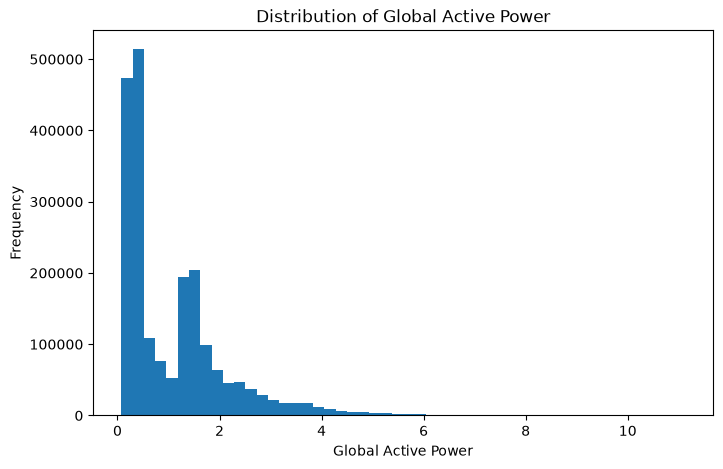

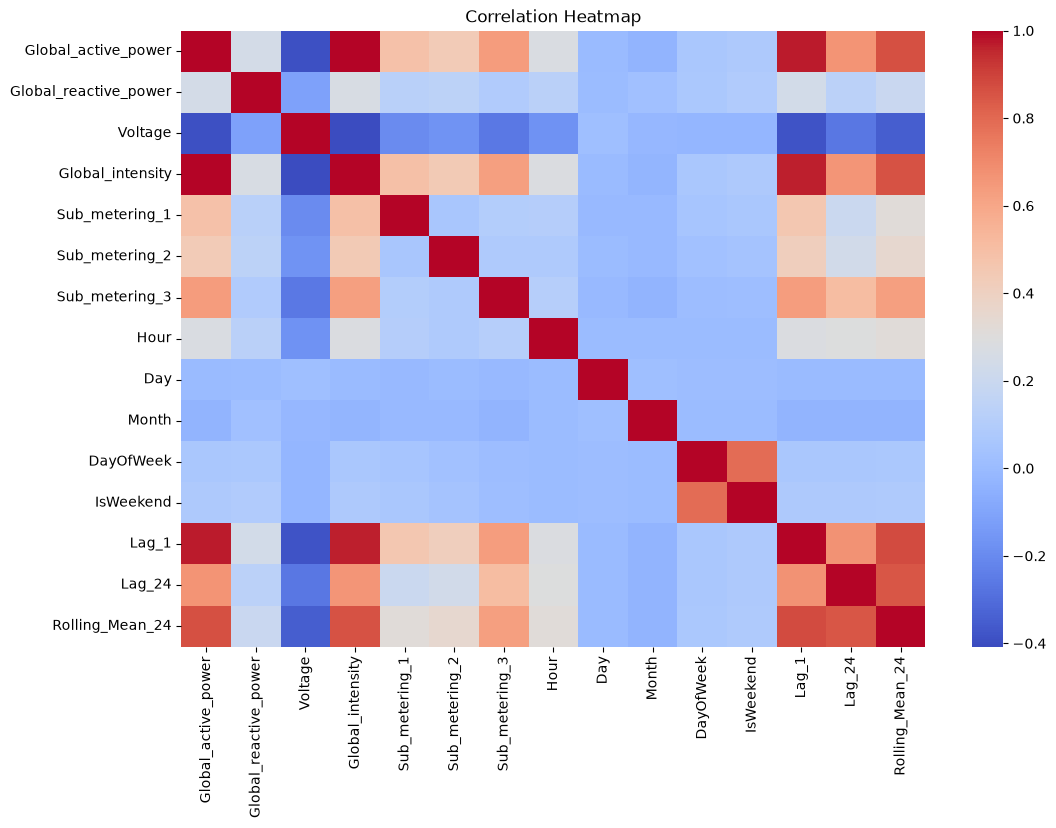

In [14]:
# ==========================================
# CELL 7 : Exploratory Data Analysis (EDA)
# ==========================================

print("Dataset Shape:", df.shape)

print("\nSummary Statistics:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# Distribution of Target Variable
plt.figure(figsize=(8,5))
plt.hist(df["Global_active_power"], bins=50)
plt.title("Distribution of Global Active Power")
plt.xlabel("Global Active Power")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# ==========================================
# CELL 8 : Create Features (X) and Target (y)
# ==========================================

# Target Variable
y = df["Global_active_power"]

# Feature Variables
X = df.drop(columns=[
    "Global_active_power",
    "Date",
    "Time"
])

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

display(X.head())

Feature Matrix Shape : (2075235, 14)
Target Shape : (2075235,)


,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day,Month,DayOfWeek,IsWeekend,Lag_1,Lag_24,Rolling_Mean_24
Datetime,,,,,,,,,,,,,,
2006-12-16 17:48:00,0.0,234.96,19.4,0.0,0.0,17.0,17,16,12,5,1,5.174,4.216,4.574917
2006-12-16 17:49:00,0.0,236.66,13.6,0.0,0.0,17.0,17,16,12,5,1,4.474,5.360,4.486917
2006-12-16 17:50:00,0.0,235.84,13.6,0.0,0.0,17.0,17,16,12,5,1,3.248,5.374,4.397833
2006-12-16 17:51:00,0.0,235.60,13.6,0.0,0.0,17.0,17,16,12,5,1,3.236,5.388,4.307833
2006-12-16 17:52:00,0.0,235.49,13.8,0.0,0.0,17.0,17,16,12,5,1,3.228,3.666,4.290833


In [16]:
print("df:", "df" in globals())
print("X:", "X" in globals())
print("y:", "y" in globals())

df: True
X: True
y: True


In [17]:
# ==========================================
# CELL 9 : Train / Validation / Test Split
# ==========================================

# 70% Train, 15% Validation, 15% Test

train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

# Train
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

# Validation
X_val = X.iloc[train_size:train_size + val_size]
y_val = y.iloc[train_size:train_size + val_size]

# Test
X_test = X.iloc[train_size + val_size:]
y_test = y.iloc[train_size + val_size:]

print("Train Shape :", X_train.shape)
print("Validation Shape :", X_val.shape)
print("Test Shape :", X_test.shape)

Train Shape : (1452664, 14)
Validation Shape : (311285, 14)
Test Shape : (311286, 14)


In [18]:
print(X_train.shape)
print(y_train.shape)

(1452664, 14)
(1452664,)


In [19]:
# ==========================================
# CELL 10 : Dummy Regressor (Baseline)
# ==========================================

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Dummy Model
dummy = DummyRegressor(strategy="mean")

# Train
dummy.fit(X_train, y_train)

# Prediction
y_pred_dummy = dummy.predict(X_val)

# Evaluation
dummy_mae = mean_absolute_error(y_val, y_pred_dummy)
dummy_rmse = np.sqrt(mean_squared_error(y_val, y_pred_dummy))
dummy_r2 = r2_score(y_val, y_pred_dummy)

print("===== Dummy Regressor =====")
print(f"MAE  : {dummy_mae:.4f}")
print(f"RMSE : {dummy_rmse:.4f}")
print(f"R²   : {dummy_r2:.4f}")

===== Dummy Regressor =====
MAE  : 0.8087
RMSE : 1.0556
R²   : -0.0246


In [20]:
# ==========================================
# CELL 11 : Linear Regression
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Model
lr = LinearRegression()

# Train Model
lr.fit(X_train, y_train)

# Prediction
y_pred_lr = lr.predict(X_val)

# Evaluation
lr_mae = mean_absolute_error(y_val, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_val, y_pred_lr))
lr_r2 = r2_score(y_val, y_pred_lr)

print("===== Linear Regression =====")
print(f"MAE  : {lr_mae:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R²   : {lr_r2:.4f}")

===== Linear Regression =====
MAE  : 0.0247
RMSE : 0.0366
R²   : 0.9988


In [21]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (1452664, 14)
y_train: (1452664,)
X_val: (311285, 14)
y_val: (311285,)


In [22]:
print(df.shape)
print(X.shape)
print(y.shape)
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)

(2075235, 17)
(2075235, 14)
(2075235,)
(1452664, 14)
(1452664,)
(311285, 14)
(311285,)


In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

print("===== Random Forest Regressor =====")
print("MAE :", mean_absolute_error(y_val, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_rf)))
print("R2  :", r2_score(y_val, y_pred_rf))

===== Random Forest Regressor =====
MAE : 0.0195673116655229
RMSE: 0.03236315029135919
R2  : 0.9990368820625247


In [25]:
# ==========================================
# Create Smaller Training Dataset
# ==========================================

X_train_small = X_train.sample(n=100000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

print(X_train_small.shape)
print(y_train_small.shape)

(100000, 14)
(100000,)


In [26]:
# ==========================================
# CELL 12B : Random Forest (Small Dataset)
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Train Model
rf.fit(X_train_small, y_train_small)

# Prediction
y_pred_rf = rf.predict(X_val)

# Evaluation
rf_mae = mean_absolute_error(y_val, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_val, y_pred_rf))
rf_r2 = r2_score(y_val, y_pred_rf)

print("===== Random Forest (Small Dataset) =====")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

===== Random Forest (Small Dataset) =====
MAE  : 0.0241
RMSE : 0.0372
R²   : 0.9987


In [27]:
# ==========================================
# CELL 13 : Gradient Boosting Regressor
# ==========================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Model
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train Model
gbr.fit(X_train_small, y_train_small)

# Prediction
y_pred_gbr = gbr.predict(X_val)

# Evaluation
gbr_mae = mean_absolute_error(y_val, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_val, y_pred_gbr))
gbr_r2 = r2_score(y_val, y_pred_gbr)

print("===== Gradient Boosting Regressor =====")
print(f"MAE  : {gbr_mae:.4f}")
print(f"RMSE : {gbr_rmse:.4f}")
print(f"R²   : {gbr_r2:.4f}")

===== Gradient Boosting Regressor =====
MAE  : 0.0201
RMSE : 0.0306
R²   : 0.9991


In [28]:
# ==========================================
# CELL 14 : Model Comparison
# ==========================================

import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Dummy Regressor",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        dummy_mae,
        lr_mae,
        rf_mae,
        gbr_mae
    ],
    "RMSE": [
        dummy_rmse,
        lr_rmse,
        rf_rmse,
        gbr_rmse
    ],
    "R2 Score": [
        dummy_r2,
        lr_r2,
        rf_r2,
        gbr_r2
    ]
})

results = results.sort_values("R2 Score", ascending=False)

print(results)

               Model       MAE      RMSE  R2 Score
3  Gradient Boosting  0.020050  0.030565  0.999141
1  Linear Regression  0.024708  0.036646  0.998765
2      Random Forest  0.024065  0.037202  0.998727
0    Dummy Regressor  0.808710  1.055566 -0.024586
